## 1. Import Libraries

In [50]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")

## 2. Import dataset

In [51]:
cars_data = pd.read_csv("Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. Data Understanding

#### 3.1 perform initial investigation on dataset

In [52]:
cars_data.shape

(81, 5)

In [53]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [54]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [55]:
cars_data.describe().round(2)

,HP,MPG,VOL,SP,WT
count,81.00,81.00,81.00,81.00,81.00
mean,117.47,34.42,98.77,121.54,32.41
std,57.11,9.13,22.30,14.18,7.49
min,49.00,12.10,50.00,99.56,15.71
25%,84.00,27.86,89.00,113.83,29.59
50%,100.00,35.15,101.00,118.21,32.73
75%,140.00,39.53,113.00,126.40,37.39
max,322.00,53.70,160.00,169.60,53.00


## Assumptions check

### Test 1. Linearity Test

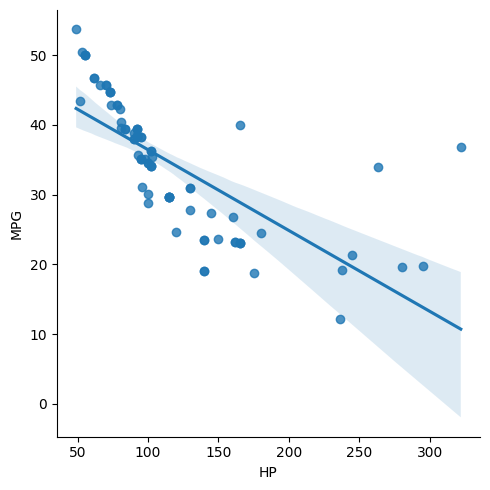

In [56]:
sns.lmplot(data = cars_data, x = "HP", y = "MPG")
plt.show()

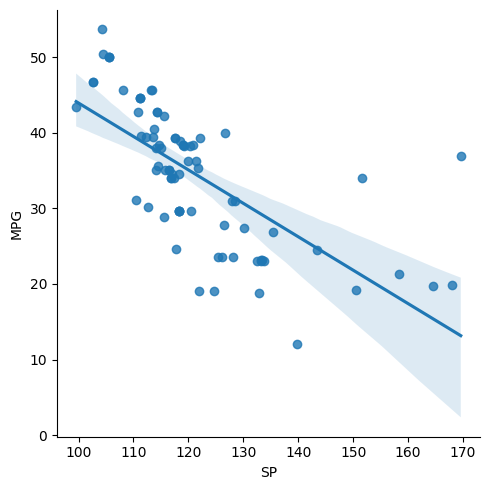

In [57]:
sns.lmplot(data = cars_data, x = "SP", y = "MPG")
plt.show()

**Test 1. Linearity Test Failed**

### Test 2. Normality Test

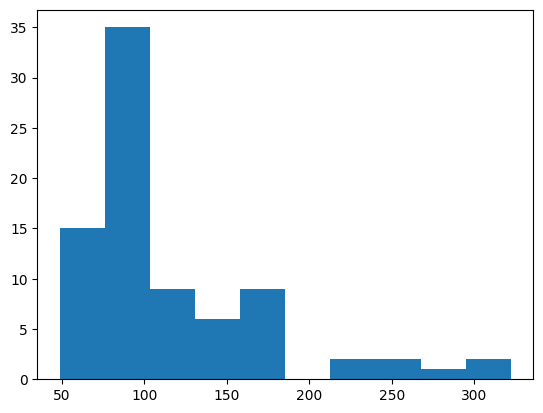

In [58]:
plt.hist(data = cars_data, x = "HP")
plt.show()

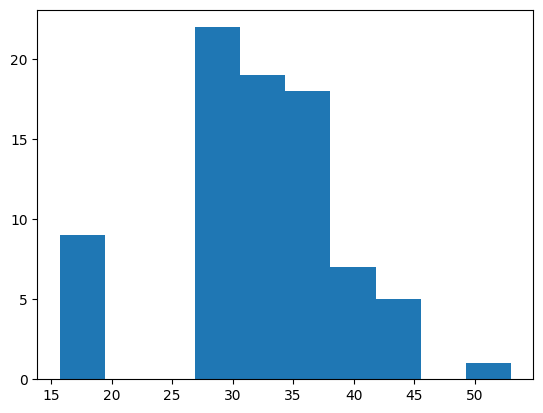

In [59]:
plt.hist(data = cars_data, x = "WT")
plt.show()

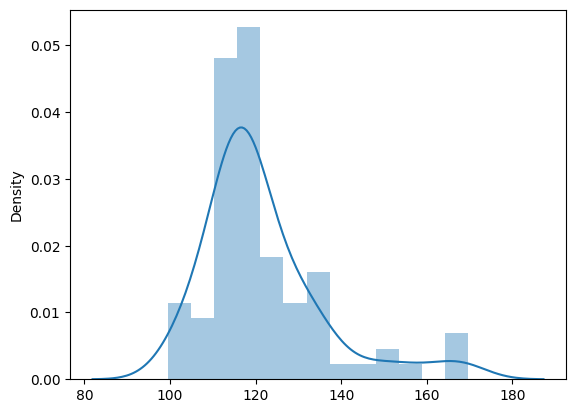

In [60]:
sns.distplot(x = cars_data["SP"])
plt.show()

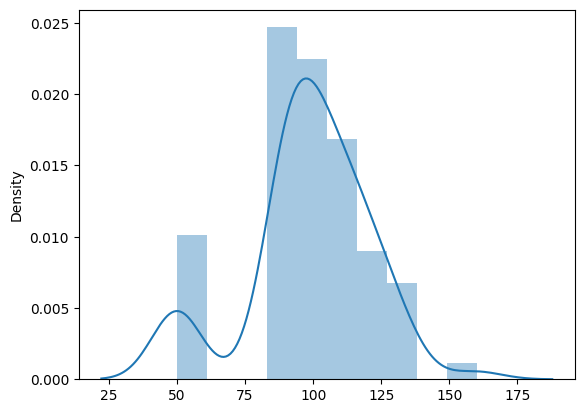

In [61]:
sns.distplot(x = cars_data["VOL"])
plt.show()

**Test 2. Normality Test also Failed**

### Test 3. Multicollinearity Test 

In [62]:
corr_matrix = cars_data.corr().round(3)
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000,-0.725,0.077,0.974,0.077
MPG,-0.725,1.000,-0.529,-0.687,-0.527
VOL,0.077,-0.529,1.000,0.102,0.999
SP,0.974,-0.687,0.102,1.000,0.102
WT,0.077,-0.527,0.999,0.102,1.000


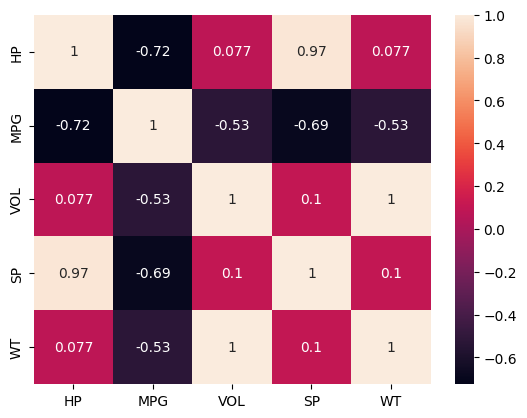

In [63]:
sns.heatmap(data = corr_matrix, annot = True)
plt.show()

**There is Multicollinearity in the data**

### Test 4. AutoRegression Test Passed 

## Step 4. Data Preparation

In [64]:
X = cars_data[["HP","VOL","SP","WT"]]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [65]:
y = cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## Step 5 Model Building

In [66]:
linear_model = LinearRegression()

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Step 6 Model Training

In [68]:
linear_model.fit(X_train,y_train)

LinearRegression()

In [69]:
linear_model.intercept_

17.72573707901552

In [70]:
linear_model.coef_

array([-0.22051886, -0.53968773,  0.53363516,  0.94526434])

## Step 7 Model Testing

In [71]:
y_pred_train = linear_model.predict(X_train)
y_pred_train

array([27.23986964, 27.95819115, 33.24875655, 40.29364807, 25.68083894,
       42.62893641, 34.73507363, 35.65466797, 24.43365831, 37.11949077,
       28.9235271 , 40.36428199, 36.42550725, 34.34806727, 15.59635557,
       46.79967595, 32.37674121, 29.12848417, 37.19492862, 26.41526801,
       46.77245271, 34.47509096, 40.69845435, 19.37848349, 42.14051045,
       48.51604266, 38.27005071, 47.28339177, 36.7659616 , 40.87329203,
       38.45089108, 22.79128741, 33.99418186, 33.34967248, 15.33615265,
       40.91216943, 38.60538243, 34.44714081, 34.71602677, 37.43625033,
       39.55207356, 36.96071556, 28.54965216, 31.92354767, 48.09957161,
       36.53966074, 25.48790773, 30.88686025, 25.83641769, 22.83714975,
       37.5605476 , 35.88779394, 41.02297786, 27.88370748, 35.80679919,
       40.76469723, 38.89141787, 20.85293321, 22.55031777, 38.12290091,
       30.19816001, 21.94334913, 40.61172901, 32.58730566])

In [72]:
y_pred_test = linear_model.predict(X_test)
y_pred_test

array([33.25194201, 41.67282126, 37.34571718, 36.03030532, 40.73634756,
       35.85831389, 40.68418569, 31.78859887, 40.38431601, 40.1859865 ,
       32.60787495, 34.54417128, 23.43464652, 36.52921002, 24.35546583,
       35.57247482, 17.15238303])

## Step 7 Model Evaluation

#### 7.1 Training data evaluatiopn metrics

MAE ,
MSE ,
RMSE ,
R2 Score

In [73]:
mean_absolute_train = mean_absolute_error(y_train,y_pred_train)
mean_squared_train = mean_squared_error(y_train,y_pred_train)
root_squared_train = root_mean_squared_error(y_train,y_pred_train)
r2_train = r2_score(y_train,y_pred_train)

print("Train MAE:", mean_absolute_train)
print("Train MSE:", mean_squared_train)
print("Train RMSE:", root_squared_train)
print("Train R2 score:", r2_train)

Train MAE: 3.2122977828889683
Train MSE: 17.40933402202664
Train RMSE: 4.172449403171552
Train R2 score: 0.7741103982497514


#### 7.2 Testing data evaluatiopn metrics

MAE ,
MSE ,
RMSE ,
R2 Score

In [74]:
mean_absolute_test = mean_absolute_error(y_test,y_pred_test)
mean_squared_test = mean_squared_error(y_test,y_pred_test)
root_squared_test = root_mean_squared_error(y_test,y_pred_test)
r2_test = r2_score(y_test,y_pred_test)

print("Test MAE:", mean_absolute_test)
print("Test MSE:", mean_squared_test)
print("Test RMSE:", root_squared_test)
print("Train R2 score:", r2_test)

Test MAE: 4.114450703773385
Test MSE: 31.964121489759805
Test RMSE: 5.653682117855567
Train R2 score: 0.6749527236507017


#### Adjusted R2 Score

In [46]:
linear_stats_model = smf.ols(formula = 'MPG ~ HP+VOL+SP+WT', data = cars_data).fit()
print("r2 score:", linear_stats_model.rsquared.round(4), "\nAdjusted R2 Score:", linear_stats_model.rsquared_adj.round(4))

r2 score: 0.5257 
Adjusted R2 Score: 0.5197


In [47]:
linear_stats_model = smf.ols(formula = 'MPG ~ HP+VOL+SP+WT', data = cars_data).fit()
print("r2 score:", linear_stats_model.rsquared.round(4), "\nAdjusted R2 Score:", linear_stats_model.rsquared_adj.round(4))

r2 score: 0.7705 
Adjusted R2 Score: 0.7585


### Test 5 Homoscadasticity Test

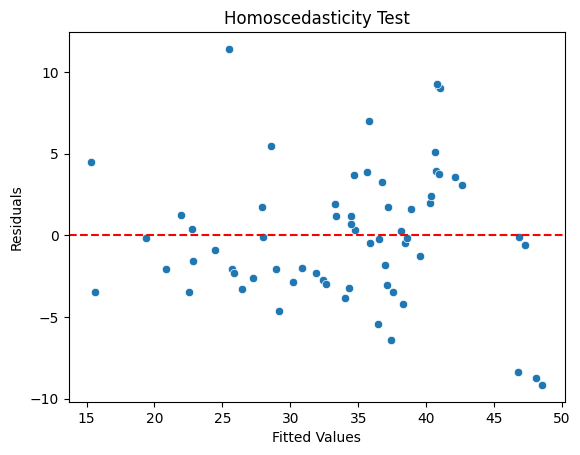

In [75]:
residuals_train = y_train - y_pred_train

sns.scatterplot(x=y_pred_train, y=residuals_train)

plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Test")
plt.show()

**Test 5. Homoscadasticity Test Failed**

### Test 6 Zero Residual Mean Test

In [77]:
sns.scatterplot(x = cars_data["MPG"], y = y_prediction)
plt.show()

NameError: name 'y_prediction' is not defined

**Test 6. Zero residual mean Test also Failed**